In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import skimage as ski
import xarray as xr
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs
from numba import jit

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260126_144901.log
/tmp/ipykernel_3362225/2496815259.py:31: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [43]:
import os

def list_files(startpath, textfile='filetree.txt'):
    if not os.path.isfile(textfile):
        with open(textfile, 'w') as fp:
            pass
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        with open(textfile, 'a') as the_file:
                the_file.write('{}{}/\n'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print('{}{}'.format(subindent, f))
            with open(textfile, 'a') as the_file:
                the_file.write('{}{}\n'.format(subindent, f))

In [44]:
list_files('/media/jbeckwith/Ezra Seagat/Leila_Stuff/')

/
20240606/
    GFPimages/
        gfp-3D - Position 1_XY1717669203_Z000_T0_C0.tif
        gfp4-ave4_XY1717669010_Z0_T0_C0.tif
        gfp1-ave3_XY1717668334_Z0_T0_C0.tif
        gfp5-ave1_XY1717669034_Z0_T0_C0.tif
        gfp4-ave4_XY1717669010_Z0_T0_C0.log
        gfp1-ave3_XY1717668334_Z0_T0_C0.log
        gfp5-ave1_XY1717669034_Z0_T0_C0.log
        gfp-3D - Position 1_XY1717669203_Z000_T0_C1.tif
        gfp5-ave1_XY1717669034_Z0_T0_C1.tif
        gfp-3D - Position 1_XY1717669203_Z000_T0_C0.log
        gfp4-ave4_XY1717669010_Z0_T0_C1.tif
        gfp1-ave3_XY1717668334_Z0_T0_C1.tif
        gfp2-ave2_XY1717668484_Z0_T0_C1.tif
        GFP-test.sld
        gfp3-ave1_XY1717668533_Z0_T0_C0.tif
        gfp2-ave2_XY1717668484_Z0_T0_C0.log
        gfp3-ave1_XY1717668533_Z0_T0_C0.log
        gfp2-ave2_XY1717668484_Z0_T0_C0.tif
        gfp3-ave1_XY1717668533_Z0_T0_C1.tif
    01-iPSC-ibidi1-Round1/
        10-IPSC-Mutant-row5-023_XY1717673492_Z0_T0_C1.tif
        12.tif
        04-IPSC-Control-

In [3]:
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Steady_State/20260126_Holliday/'

In [7]:
excitation_files = H_F.file_search(folder, 'EzspecCompatible', 'Excitation')

In [35]:
folder2 = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Steady_State/Duetta/20260126_HollidayReAnnealed/'
excitation_files = H_F.file_search(folder2, 'EzspecCompatible', 'Excitation')

In [37]:
excitation_5mM_RA = pd.read_csv(excitation_files[1], sep='\t', header=3, skipfooter=2)
excitation_50mM_RA = pd.read_csv(excitation_files[3], sep='\t', header=3, skipfooter=2)
excitation_100mM_RA = pd.read_csv(excitation_files[5], sep='\t', header=3, skipfooter=2)

/tmp/ipykernel_3362225/3749109200.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_5mM_RA = pd.read_csv(excitation_files[1], sep='\t', header=3, skipfooter=2)
/tmp/ipykernel_3362225/3749109200.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_50mM_RA = pd.read_csv(excitation_files[3], sep='\t', header=3, skipfooter=2)
/tmp/ipykernel_3362225/3749109200.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_100mM_RA = pd.read_csv(excitation_files[5], sep='\t', header=3, skipfooter=2)


In [18]:
excitation_5mM = pd.read_csv(excitation_files[0], sep='\t', header=3, skipfooter=2)
excitation_50mM = pd.read_csv(excitation_files[2], sep='\t', header=3, skipfooter=2)

/tmp/ipykernel_3362225/858778382.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_5mM = pd.read_csv(excitation_files[0], sep='\t', header=3, skipfooter=2)
/tmp/ipykernel_3362225/858778382.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_50mM = pd.read_csv(excitation_files[2], sep='\t', header=3, skipfooter=2)


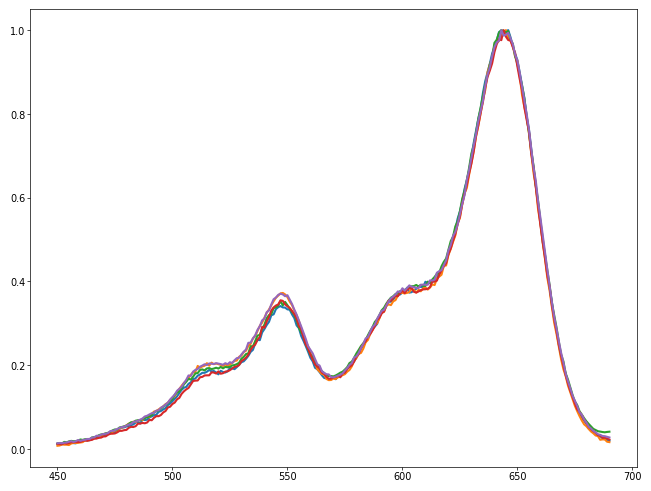

In [38]:
plt.plot(excitation_5mM.X, excitation_5mM.Y/np.max(excitation_5mM.Y))
plt.plot(excitation_50mM.X, excitation_50mM.Y/np.max(excitation_50mM.Y))

plt.plot(excitation_5mM_RA.X, excitation_5mM_RA.Y/np.max(excitation_5mM_RA.Y))
plt.plot(excitation_50mM_RA.X, excitation_50mM_RA.Y/np.max(excitation_50mM_RA.Y))
plt.plot(excitation_100mM_RA.X, excitation_100mM_RA.Y/np.max(excitation_100mM_RA.Y))

In [22]:
excitation_5mM_Cy3 = pd.read_csv(excitation_files[1], sep='\t', header=3, skipfooter=2)
excitation_50mM_Cy3 = pd.read_csv(excitation_files[3], sep='\t', header=3, skipfooter=2)

/tmp/ipykernel_3362225/3664587744.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_5mM_Cy3 = pd.read_csv(excitation_files[1], sep='\t', header=3, skipfooter=2)
/tmp/ipykernel_3362225/3664587744.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  excitation_50mM_Cy3 = pd.read_csv(excitation_files[3], sep='\t', header=3, skipfooter=2)


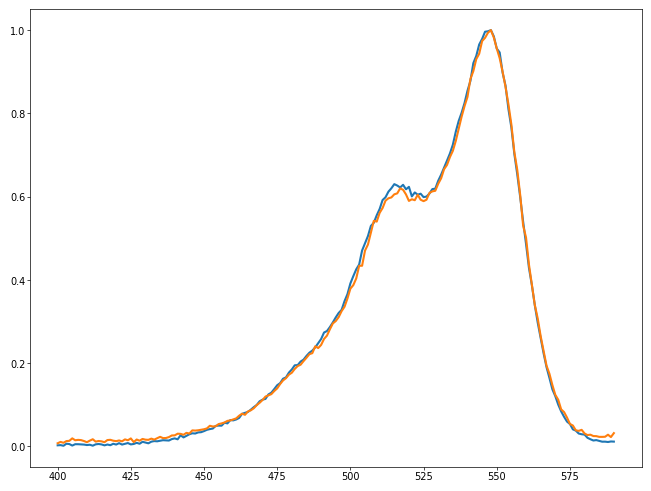

In [23]:
plt.plot(excitation_5mM_Cy3.X, excitation_5mM_Cy3.Y/np.max(excitation_5mM_Cy3.Y))
plt.plot(excitation_50mM_Cy3.X, excitation_50mM_Cy3.Y/np.max(excitation_50mM_Cy3.Y))

In [24]:
EEM_files = H_F.file_search(folder, 'EzspecCompatible', 'EEM')

In [26]:
data_5mM_EEM = pd.read_csv(EEM_files[0], sep='\t', header=3, skipfooter=2)

/tmp/ipykernel_3362225/2971813088.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  data_5mM_EEM = pd.read_csv(EEM_files[0], sep='\t', header=3, skipfooter=2)


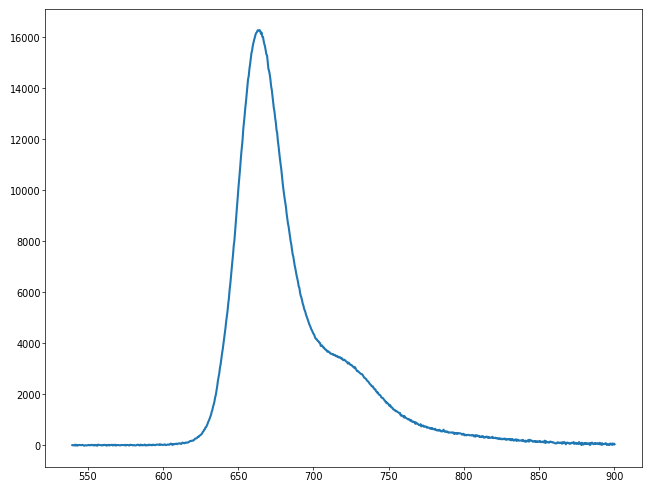

In [32]:
plt.plot(data_5mM_EEM.X, data_5mM_EEM.Y)